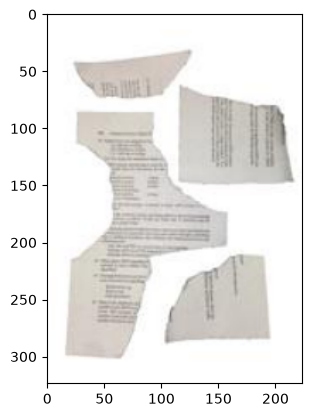

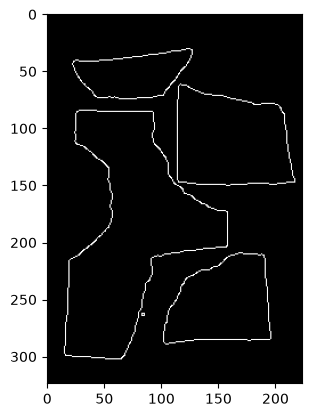

In [115]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
image_path = r'D:\PythonProject1\Intern\Images\image.png'
image = cv2.imread(image_path)
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred_image = cv2.GaussianBlur(gray_image, (3,3), 0)
_, thresh = cv2.threshold(gray_image, 240, 245, cv2.THRESH_BINARY_INV)
canny = cv2.Canny(thresh,50,150)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()
plt.imshow(canny, cmap='gray')
plt.show()

In [116]:
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
# contours, _ = cv2.findContours(thresh,(cv2.RETR_LIST,cv2.RETR_CCOMP,cv2.RETR_TREE), cv2.CHAIN_APPROX_SAMPLE)



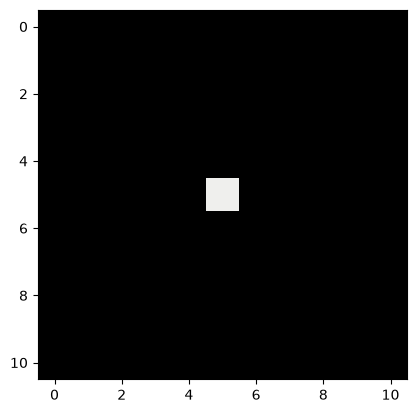

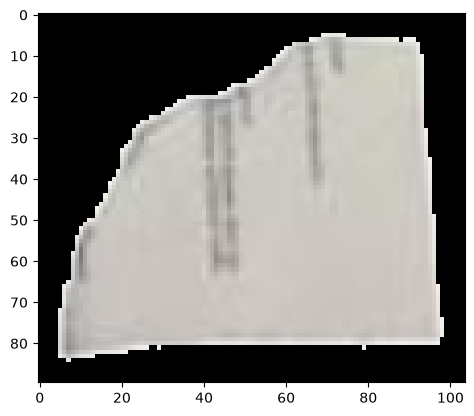

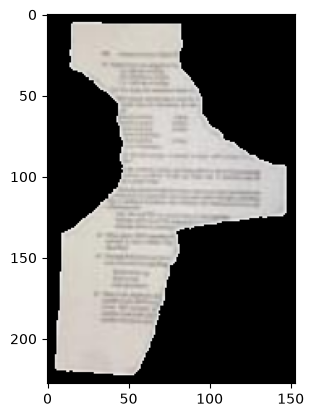

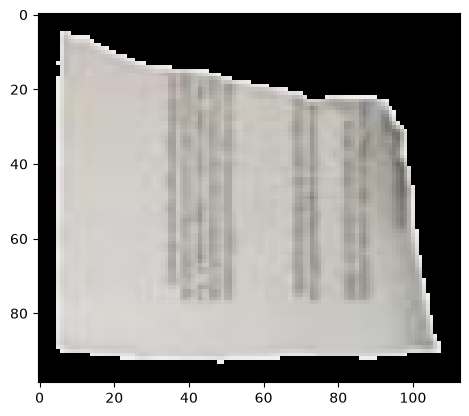

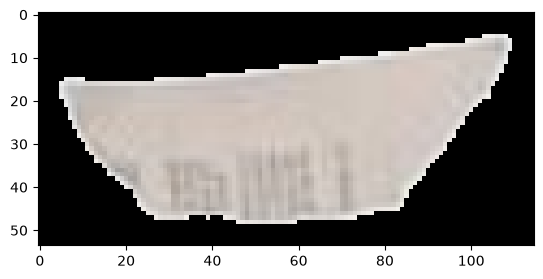

In [ ]:
for  contour in contours:
    x, y, w, h = cv2.boundingRect(contour)
    pad = 5
    x_start, x_end = max(0, x - pad), min(image.shape[1], x + w + pad)
    y_start, y_end = max(0, y - pad), min(image.shape[0], y + h + pad)
    
    cropped_piece = image[y_start:y_end, x_start:x_end]
    
    mask = np.zeros_like(thresh)
    cv2.drawContours(mask, [contour], -1, 255, -1) 

    cropped_mask = mask[y_start:y_end, x_start:x_end]
    
    isolated_piece = cv2.bitwise_and(cropped_piece, cropped_piece, mask=cropped_mask)
    
    plt.figure()
    plt.imshow(cv2.cvtColor(isolated_piece, cv2.COLOR_BGR2RGB))
    plt.show()
